# Gaussian Process Regression

## Objective

- I would like to know what is the performace of a Gaussian Process regression considering that I have the numerical solution of the dynamic of the system and which **Kernel** should I use in order to get a good representation
- I would also like to have a non-linear regression using the know equations and determine the accuracy 

In [1]:
import numpy as np
from sklearn.gaussian_process import kernels, GaussianProcessRegressor
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
fln_df_trajectories = "../NumericalSolutions/src/c_001_deterministic/df_trajectories_N_7.csv"
df_trajectories = pd.read_csv(fln_df_trajectories)
df_trajectories

,Time,Species.1,Species.2,Species.3,Species.4,Species.5,Species.6,Species.7
0,0.0,31.6228,7.24436,3.46737,1.44544,0.933254,0.933254,1.20226
1,0.1,31.0247,7.20240,3.45158,1.42933,0.921628,0.929077,1.18377
2,0.2,30.3814,7.08461,3.40459,1.38207,0.882147,0.916604,1.15080
3,0.3,29.7986,6.91491,3.33241,1.31139,0.826284,0.897380,1.11898
4,0.4,29.2707,6.71216,3.24067,1.22478,0.764468,0.872862,1.08978
...,...,...,...,...,...,...,...,...
4496,449.6,31.6228,7.24436,3.46737,1.44544,0.933254,0.933254,1.20226
4497,449.7,31.6228,7.24436,3.46737,1.44544,0.933254,0.933254,1.20226
4498,449.8,31.6228,7.24436,3.46737,1.44544,0.933254,0.933254,1.20226
4499,449.9,31.6228,7.24436,3.46737,1.44544,0.933254,0.933254,1.20226


In [3]:
df_trajectories_pl = df_trajectories.melt(id_vars=['Time'], var_name="Species", value_name="Abundance")
df_trajectories_pl['Species'] = df_trajectories_pl['Species'].str.replace("Species.", "").astype(int)
df_trajectories_pl

,Time,Species,Abundance
0,0.0,1,31.62280
1,0.1,1,31.02470
2,0.2,1,30.38140
3,0.3,1,29.79860
4,0.4,1,29.27070
...,...,...,...
31502,449.6,7,1.20226
31503,449.7,7,1.20226
31504,449.8,7,1.20226
31505,449.9,7,1.20226


In [4]:
# px.line(df_trajectories, x='Time', y='Species.1')
fig = px.line(
    df_trajectories_pl, x='Time', y='Abundance', color='Species'
)
fig.update_layout(yaxis_type='log')

## Inference

In [5]:
time_thresh = 50
df_trajectories_short = df_trajectories[df_trajectories['Time'] < time_thresh]

In [6]:
np.random.seed(42)
n_points = 10
idx_random = np.random.choice(df_trajectories_short.index, n_points)
idx_random

array([102, 435, 348, 270, 106,  71, 188,  20, 102, 121])

In [7]:
df_trajectories_idx_random = df_trajectories.iloc[idx_random]
df_trajectories_idx_random

,Time,Species.1,Species.2,Species.3,Species.4,Species.5,Species.6,Species.7
102,10.2,29.1382,5.11157,0.213098,0.001055,0.429960,0.041701,1.039640
435,43.5,31.6205,7.24254,3.464600,1.318910,0.932669,0.932389,1.202020
348,34.8,31.6086,7.23306,3.450040,1.189200,0.929419,0.927731,1.200650
270,27.0,31.5498,7.18618,3.369260,0.964139,0.902867,0.896772,1.188790
106,10.6,29.3384,5.30323,0.234493,0.001307,0.492465,0.045096,1.048460
71,7.1,26.8579,3.00922,0.162930,0.000643,0.008585,0.036696,0.923802
188,18.8,31.2146,6.91702,2.351980,0.318130,0.616796,0.488027,1.045950
20,2.0,25.2336,3.78573,1.452670,0.171079,0.167483,0.386520,0.852902
102,10.2,29.1382,5.11157,0.213098,0.001055,0.429960,0.041701,1.039640
121,12.1,29.9557,5.86507,0.361353,0.003520,0.597140,0.065544,1.070380


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Linear regression
linear_regressor = LinearRegression()

# Gaussian Process Regressor
## kernel definition 
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=10.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-10, 1e+1))

gp_regressor = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)



In [9]:
# Input Data
X = df_trajectories_idx_random['Time'].values.reshape(-1, 1)
y = df_trajectories_idx_random['Species.2'].values


In [10]:
# Fit the model to your data
linear_regressor.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
gp_regressor.fit(X, y)


/home/alfaceor/anaconda3/envs/GLV_cpp/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning:

lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html

/home/alfaceor/anaconda3/envs/GLV_cpp/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.



,kernel,1**2 * RBF(le...ise_level=0.1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,1**2 * RBF(length_scale=10)
,kernel__k2,WhiteKernel(noise_level=0.1)
,kernel__k1__k1,1**2


In [12]:
X_pred = np.linspace(X.min(), X.max(), 50).reshape(-1, 1)
y_pred_lin_reg = linear_regressor.predict(X_pred)
# sigma_lin_reg
y_pred_gp_reg, sigma_gp_reg = gp_regressor.predict(X_pred, return_std=True)

y_lower_bound_gp_reg = y_pred_gp_reg - 1.96 * sigma_gp_reg
y_upper_bound_gp_reg = y_pred_gp_reg + 1.96 * sigma_gp_reg

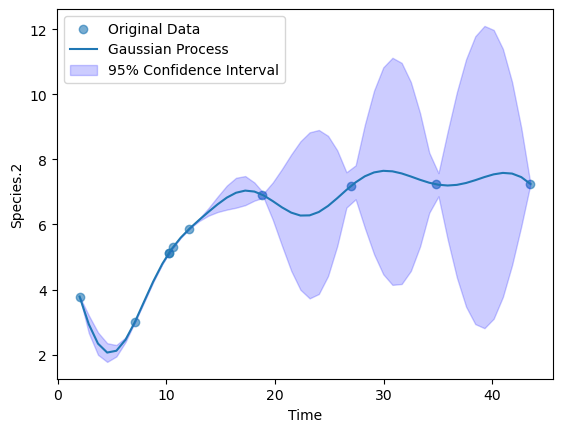

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.scatter(X, y, label='Original Data', alpha=0.6)
# ax.plot(X_pred, y_pred_lin_reg, label='Linear')
ax.plot(X_pred, y_pred_gp_reg, label='Gaussian Process')
ax.fill_between(X_pred.ravel(), y_lower_bound_gp_reg, y_upper_bound_gp_reg,
                 alpha=0.2, color='blue', label='95% Confidence Interval')

ax.set_xlabel('Time')
ax.set_ylabel('Species.2')
ax.legend()
ax.grid(False)
# plt.show()



In [14]:
import plotly.graph_objects as go

fig = go.Figure()

# 1. Plot the 95% Confidence Interval (Equivalent to ax.fill_between)
# This is done using a single 'scatter' trace in 'lines' mode with 'fill' set to 'tonexty' for the upper bound,
# and another 'scatter' trace for the lower bound which is connected to the upper bound.

# Lower Bound (Invisible line to establish the starting point of the fill)
fig.add_trace(go.Scatter(
    x=X_pred.ravel(),
    y=y_lower_bound_gp_reg,
    line=dict(width=0), # Make the line invisible
    showlegend=False, # Don't show this trace in the legend
    name='_lower_ci' # Internal name
))

# Upper Bound (Fills the area up to the lower bound)
fig.add_trace(go.Scatter(
    x=X_pred.ravel(),
    y=y_upper_bound_gp_reg,
    fill='tonexty', # Fill the area down to the previous trace ('lower_ci')
    fillcolor='rgba(0,0,255,0.2)', # Blue color with 20% opacity (alpha=0.2)
    line=dict(width=0), # Make the line invisible
    mode='lines',
    name='95% Confidence Interval' # This will be the legend entry for the filled area
))

# 2. Plot the Linear Regression Prediction (Equivalent to ax.plot)
fig.add_trace(go.Scatter(
    x=X_pred.ravel(),
    y=y_pred_lin_reg,
    mode='lines',
    name='Linear',
    line=dict(color='orange')
))

# 3. Plot the Gaussian Process Prediction (Equivalent to ax.plot)
fig.add_trace(go.Scatter(
    x=X_pred.ravel(),
    y=y_pred_gp_reg,
    mode='lines',
    name='Gaussian Process',
    line=dict(color='blue')
))

# 4. Plot the Original Data (Equivalent to ax.scatter)
fig.add_trace(go.Scatter(
    x=X.ravel(),
    y=y,
    mode='markers',
    name='Original Data',
    marker=dict(opacity=0.6, color='black')
))


# Define axis properties for cleaner, black lines and visible ticks
axis_style = dict(
    showgrid=False,
    zeroline=False,
    showline=True,        # Show the axis line
    linecolor='black',    # Make the axis line black
    linewidth=2,          # Thicker line
    ticks='outside',      # Explicitly show ticks
    tickcolor='black',    # Make ticks black
    mirror=False,         # Crucial: Setting mirror=False removes the line and ticks on the opposite side (top/right)
)

# 5. Set Axes Labels, Legend, and Layout (Equivalent to ax.set_xlabel, ax.set_ylabel, ax.legend, ax.grid(False))
fig.update_layout(
    xaxis_title="$\\tau$",
    yaxis_title="$S_2$",
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        # x=0.01
        x = 1.05
    ),
    # Adjust dimensions (less wide)
    width=900,
    height=500,
    # Increase font size for all text elements
    font=dict(
        color='black', # Set all text to black
        size=18
    ),

    # Remove the light blue background (using 'plotly_white' template)
    template='plotly_white', 

    # Optional: Set a title for the plot
    title='Model Predictions with Gaussian Process Uncertainty ',
    # To mimic ax.grid(False), Plotly's default is often less intrusive,
    # but you can explicitly remove grid lines if necessary:
    # xaxis=dict(showgrid=False),
    yaxis=dict(
        **axis_style
    ),
    xaxis=dict(
        range=[0.0, 50.0],  # <--- This defines the x-axis limits
        # title='Time',
        **axis_style
    )
)



In [18]:
# fig.write_image('test.pdf')
# fig.write_html('test.html')

## Analysis



In [ ]:
import statsmodels.api as sm
